**Loading the required libraries**

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


**Downloading the stock data**

In [3]:
df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')
df = df[['Close']]
df.dropna(inplace=True)

/tmp/ipykernel_3498/2960833772.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


**Splitting into training and testing data**

In [4]:
train_size = int(len(df) * 0.8)

train_data = df[:train_size]
test_data = df[train_size:]


**Preprocessing of data**

In [5]:
# Fit scaler only on training data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(train_data.values)

# Transform test data using the same scaler
scaled_test = scaler.transform(test_data.values)


**Creating sequences**

In [6]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(scaled_train, window_size)
X_test, y_test = create_sequences(scaled_test, window_size)

# Reshape for LSTM input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1751, 60, 1) (1751,)
Test shape: (393, 60, 1) (393,)


**Building LSTM Model**

In [7]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Training the model**

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0099 - val_loss: 0.0051
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0016 - val_loss: 0.0085
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0013 - val_loss: 0.0014


**Making predictions**

In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


**Inverse Transform**

In [10]:
train_pred_prices = scaler.inverse_transform(train_pred)
test_pred_prices  = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual  = scaler.inverse_transform(y_test.reshape(-1, 1))


**Training metrics**

In [11]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred_prices))
train_mae  = mean_absolute_error(y_train_actual, train_pred_prices)
train_r2   = r2_score(y_train_actual, train_pred_prices)

test_rmse  = np.sqrt(mean_squared_error(y_test_actual, test_pred_prices))
test_mae   = mean_absolute_error(y_test_actual, test_pred_prices)
test_r2    = r2_score(y_test_actual, test_pred_prices)

print("=" * 40)
print(f"{'Metric':<10} {'Train':>10} {'Test':>10}")
print("=" * 40)
print(f"{'RMSE':<10} {train_rmse:>10.2f} {test_rmse:>10.2f}")
print(f"{'MAE':<10} {train_mae:>10.2f} {test_mae:>10.2f}")
print(f"{'R²':<10} {train_r2:>10.4f} {test_r2:>10.4f}")
print("=" * 40)

Metric          Train       Test
RMSE             2.87       5.81
MAE              1.81       4.94
R²             0.9956     0.9086


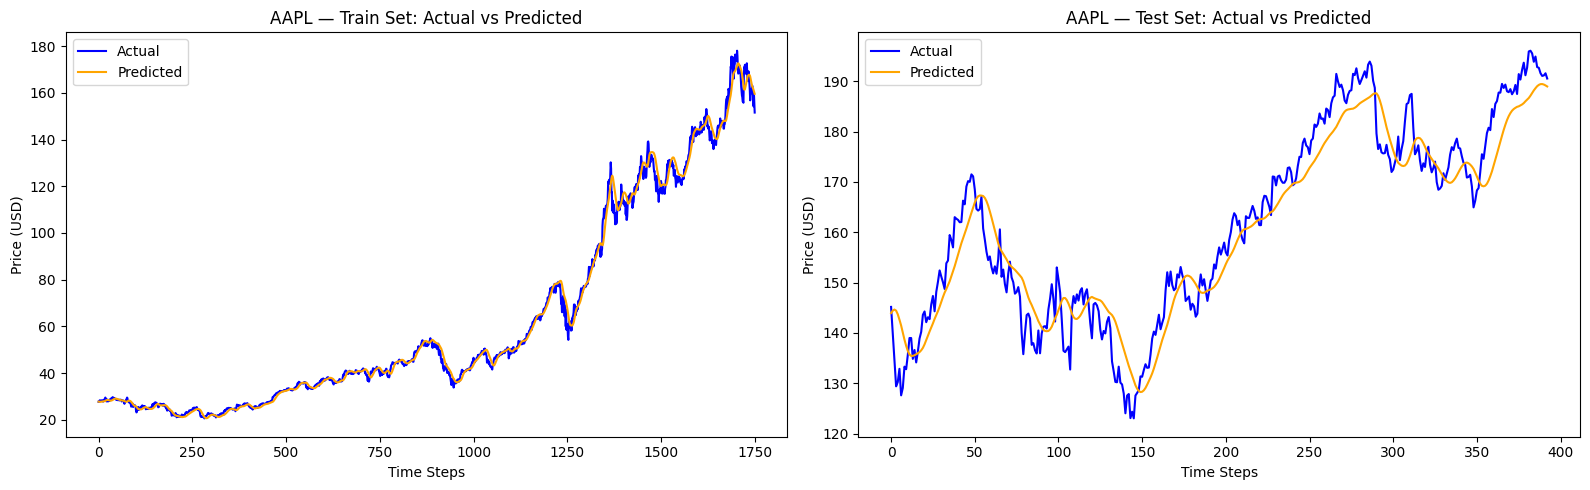

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_train_actual, label='Actual', color='blue')
axes[0].plot(train_pred_prices, label='Predicted', color='orange')
axes[0].set_title('AAPL — Train Set: Actual vs Predicted')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(y_test_actual, label='Actual', color='blue')
axes[1].plot(test_pred_prices, label='Predicted', color='orange')
axes[1].set_title('AAPL — Test Set: Actual vs Predicted')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()